In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import random
import math
import csv

%matplotlib inline

In [2]:
def polygon_chord(mu_x, mu_y, phi, ri_x, ri_y, vi_x, vi_y):
    vmu_x = np.cos(phi)
    vmu_y = np.sin(phi)
    #
    c1 = mu_x - ri_x
    c2 = mu_y - ri_y
    D = vi_x * vmu_y - vi_y * vmu_x
    #
    t = ( c1 * vmu_y - c2 * vmu_x ) / D
    s = ( vi_y * c1 - vi_x * c2 ) / D
    #
    status = np.column_stack((vi_x, ri_x, vi_y, ri_y, t, s))
    mask = (status[:,4] >= 0) & (status[:,4] < 1) & (status[:,5] >= 0)
    #
    #return mask
    #if mask.shape
    #return status[mask]
    x_int = status[mask][:,0]*status[mask][:,4] + status[mask][:,1]
    y_int = status[mask][:,2]*status[mask][:,4] + status[mask][:,3]
    
    #dist = np.sort(
    #        np.squeeze(np.sqrt((x_int - mu_x) ** 2 + (y_int - mu_y) ** 2))
    #)
    #sign_arr = np.ones(x_int.shape[0])
    #if x_int.shape[0] % 2 == 0:
    #    sign_arr[0::2] = -1
    #    return np.sum(dist * sign_arr)
    #    
    #sign_arr[1::2] = -1
    #return np.sum(dist * sign_arr)
    
    #print(x_int)
    #print(y_int)
    if x_int.shape[0] == 0 :
        return 0.0
    elif x_int.shape[0] == 1:
        return np.squeeze(np.sqrt((x_int - mu_x) ** 2 + (y_int - mu_y) ** 2)) 
    elif x_int.shape[0] == 2:
        return np.squeeze(np.sqrt((x_int[0] - x_int[1]) ** 2 + (y_int[0] - y_int[1]) ** 2))
    else:
        dist = np.sort(
            np.squeeze(np.sqrt((x_int - mu_x) ** 2 + (y_int - mu_y) ** 2))
        )
        sign_arr = np.ones(x_int.shape[0])
        if x_int.shape[0] % 2 == 0:
            sign_arr[0::2] = -1
            return np.sum(dist * sign_arr)
        
        sign_arr[1::2] = -1
        return np.sum(dist * sign_arr)

In [3]:
lst_segment = np.loadtxt("./lst_contour_vi_vf.csv", delimiter=" ")
ri_x = lst_segment[:,0]
ri_y = lst_segment[:,1]
rf_x = lst_segment[:,2]
rf_y = lst_segment[:,3]
#dt = np.ones(len(rf_y))

In [4]:
(ri_x[0:-2] - rf_x[1:-1])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [5]:
vi_x = (rf_x - ri_x)
vi_y = (rf_y - ri_y)

In [6]:
mu_x = 600
mu_y = 0
phi = 90.0 * np.pi / 180.0
#phi = np.linspace(0,2 * np.pi, 100)
#vmu_x = np.cos(phi)
#vmu_y = np.sin(phi)
res=polygon_chord(mu_x, mu_y, phi, ri_x, ri_y, vi_x, vi_y)
#mu_phi = np.linspace(0,2.0 * np.pi,10)

In [7]:
phi = np.linspace(0,2 * np.pi, 1000)
res = [polygon_chord(mu_x, mu_y, phi[i], ri_x, ri_y, vi_x, vi_y) for i in np.arange(len(phi))]

In [8]:
#np.array(res)

In [9]:
#res

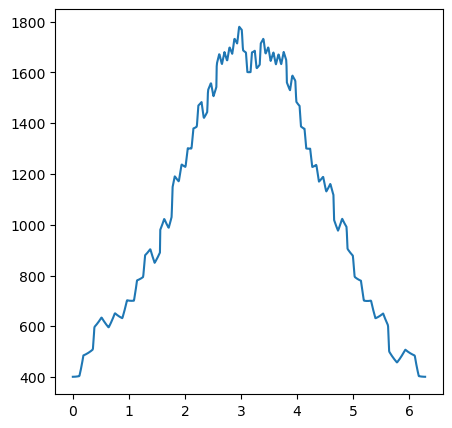

In [10]:
plt.figure(figsize=(5, 5))
plt.plot(phi, res)
plt.show()

In [12]:
np.sum(np.ones(0) - 1.0)

np.float64(0.0)

In [13]:
np.sum(np.ones(1) - 1.0)

np.float64(0.0)